# Fitted parameters: calibration and independent validation

This Notebook validates the fitted profile and does not reuse historical policy conclusions.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd()
OUT=ROOT/'reliable-calibration'
parameters=json.loads((OUT/'parameters.json').read_text(encoding='utf-8'))
display(pd.read_csv(OUT/'parameter-comparison.csv'))

,parameter,old,new,p025,p975
0,beta_income,1.024624,1.077565,0.830367,1.287229
1,beta_jobs,1.244337,1.225962,1.215815,1.244544
2,beta_rent,0.701948,0.251083,0.000000,0.702444
3,beta_distance,0.311724,0.599035,0.222478,0.745299
4,beta_education,0.461513,0.502213,0.439331,0.546431
5,beta_childcare,0.521001,0.527163,0.500584,0.548231
6,beta_current_state_1000x20,3.925000,3.825000,3.805000,3.845000
7,beta_current_state_600x12,3.925000,3.820000,3.784875,3.850000
8,beta_current_state_600x15,3.925000,3.820000,3.780000,3.830000


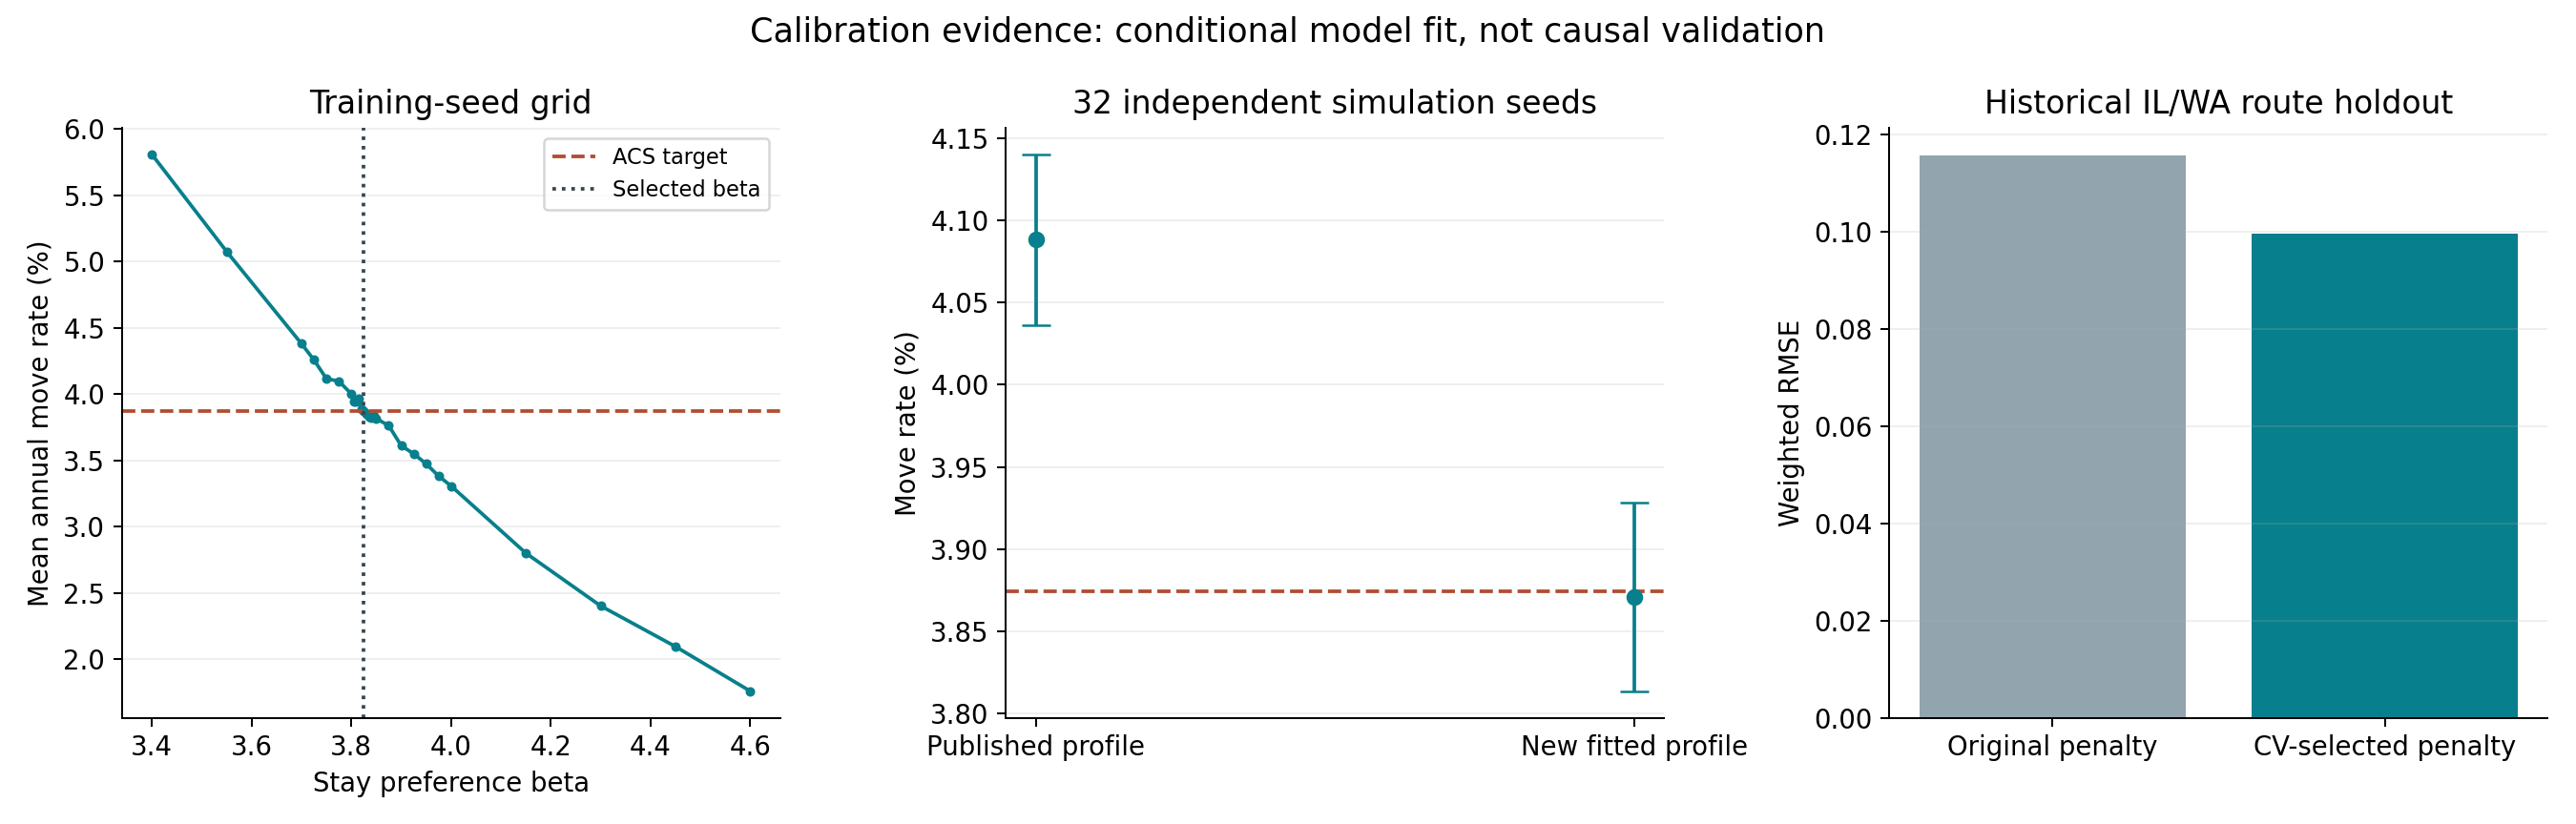

,profile,n_seeds,mean,ci95_low,ci95_high,ci95_halfwidth,seed_sd,absolute_bias,relative_bias
0,original,32,0.040881,0.040362,0.041401,0.000520,0.001441,0.002135,NaN
1,new,32,0.038709,0.038136,0.039283,0.000573,0.001590,0.000036,-0.000939


In [2]:
display(Image(filename=str(OUT/'calibration-evidence.png')))
beta=json.loads((OUT/'beta-fit-report.json').read_text())
display(pd.DataFrame([{'profile':'original',**beta['validation_published']},{'profile':'new',**beta['validation_new']}]))
assert beta['training_criterion_passed'] and beta['validation_criteria_passed']

In [3]:
from reliable_worker import run
case={'profile':'new','seed':1901,'n_agents':1000,'years':20,'beta_current_state':parameters['beta_current_state']}
live=run(case)
records=[json.loads(line) for line in (OUT/'beta-live.jsonl').read_text().splitlines()]
previous=next(r['result'] for r in records if r['case']==case)
difference=max(abs(live[k]-previous[k]) for k in live)
assert difference<1e-12
print('Actual model repeat maximum difference:',difference)
print('Live migration rate:',live['move_rate'])

Actual model repeat maximum difference: 0.0
Live migration rate: 0.03625000000000001


In [4]:
research=json.loads((OUT/'research-design-fit-report.json').read_text())
assert research['training_criterion_passed'] and research['validation_criteria_passed']
case={'profile':'new','seed':3001,'n_agents':600,'years':12,'beta_current_state':parameters['beta_by_design']['600x12']}
live=run(case)
records=[json.loads(line) for line in (OUT/'research-design-live.jsonl').read_text().splitlines()]
previous=next(r['result'] for r in records if r['case']==case)
difference=max(abs(live[k]-previous[k]) for k in live)
assert difference<1e-12
print('600x12 actual repeat maximum difference:',difference)
display(pd.DataFrame([research['validation_new']]))

600x12 actual repeat maximum difference: 0.0


,n_seeds,mean,ci95_low,ci95_high,ci95_halfwidth,seed_sd,absolute_bias
0,32,0.038763,0.037755,0.039771,0.001008,0.002796,0.000017


In [5]:
precision=json.loads((OUT/'precision-fix-report.json').read_text())
assert precision['passed'] and precision['mismatch_count']==0
print('Canonical precision verification:',precision['published_setting_rows'],'rows;',precision['numeric_metrics_checked'],'metrics; zero differences')

Canonical precision verification: 752 rows; 5648 metrics; zero differences


The checks demonstrate conditional simulator fit and reproducible execution. Simulation intervals exclude survey sampling and structural uncertainty. All research policy tables are separately rerun in data/research.